In [1]:
import sys
import os


sys.path.insert(0, os.path.abspath("../src"))

print(os.getcwd())
print(os.listdir("../src"))

/Users/ulrichfossokako/Desktop/DOCS/usb /Cours et entretiens/MASTER FINANCE/GFN260 Hybride Machine Learning/market-sentiment-trading-ml/notebooks
['config.py', 'news_loader.py', 'models.py', 'sentiment.py', 'data_loader.py', '__init__.py', 'features.py', 'sentiment_news.py', '.ipynb_checkpoints', 'main.py', 'backtest.py']


In [2]:
import os
print(os.listdir("../src"))

['config.py', 'news_loader.py', 'models.py', 'sentiment.py', 'data_loader.py', '__init__.py', 'features.py', 'sentiment_news.py', '.ipynb_checkpoints', 'main.py', 'backtest.py']


In [3]:
import importlib
import sentiment_news
importlib.reload(sentiment_news)

/Users/ulrichfossokako/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/ulrichfossokako/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ulrichfossokako/Library/Python/3.9/lib/python/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


<module 'sentiment_news' from '/Users/ulrichfossokako/Desktop/DOCS/usb /Cours et entretiens/MASTER FINANCE/GFN260 Hybride Machine Learning/market-sentiment-trading-ml/src/sentiment_news.py'>

In [4]:
from sentiment_news import score_news_sentiment, aggregate_daily_sentiment

In [5]:
import pandas as pd

news = pd.read_csv("../data/raw/boursorama_news.csv")
news["date"] = pd.to_datetime(news["date"])

news.head()
news_scored = score_news_sentiment(news)
daily_sentiment = aggregate_daily_sentiment(news_scored)

In [6]:
news_scored = score_news_sentiment(news)
daily_sentiment = aggregate_daily_sentiment(news_scored)

daily_sentiment.head()

,date,news_count,sentiment_mean,sentiment_std,sentiment_positive_ratio,sentiment_negative_ratio
0,2026-05-06,161,-0.037392,0.197953,0.080745,0.236025


In [7]:
import os
import pandas as pd
from sentiment_news import score_news_sentiment, aggregate_daily_sentiment

# Charger les news
news = pd.read_csv("../data/raw/boursorama_news.csv")
news["date"] = pd.to_datetime(news["date"])

# Calcul du sentiment
news_scored = score_news_sentiment(news)

In [8]:
news_scored.tail()

,date,source,text,sentiment_score,sentiment_label
156,2026-05-06,boursorama,00'39 Travail le 1er-Mai: le Conseil d'Etat ex...,0.0000,neutral
157,2026-05-06,boursorama,01'55 Crise des opioïdes aux États-Unis: Purdu...,0.0000,neutral
158,2026-05-06,boursorama,00'40 Magyar à Bruxelles pour tourner la page ...,0.0000,neutral
159,2026-05-06,boursorama,"00'35 Procès libyen: Sarkozy contredit Guéant,...",-0.4215,negative
160,2026-05-06,boursorama,01'39 Nutri-Score : vers une obligation pour t...,0.0000,neutral


In [9]:
# Agrégation journalière
daily_sentiment = aggregate_daily_sentiment(news_scored)

# Créer le dossier si besoin
os.makedirs("../data/processed", exist_ok=True)

# Sauvegarde
daily_sentiment.to_csv("../data/processed/daily_sentiment.csv", index=False)

print("Fichier créé ✅")
daily_sentiment.head()

Fichier créé ✅


,date,news_count,sentiment_mean,sentiment_std,sentiment_positive_ratio,sentiment_negative_ratio
0,2026-05-06,161,-0.037392,0.197953,0.080745,0.236025


In [10]:
import os
print(os.listdir("../data/processed"))

['backtest_final.csv', 'news_scored_finbert_ticker.csv', 'daily_sentiment.csv', 'news_scored_finbert.csv', 'prices.csv', 'daily_sentiment_finbert_ticker.csv', 'macro_market_data.csv', 'daily_sentiment_finbert.csv', '.ipynb_checkpoints']


In [11]:
import sys
!{sys.executable} -m pip install --upgrade torch transformers

Defaulting to user installation because normal site-packages is not writeable
  Using cached transformers-4.57.6-py3-none-any.whl.metadata (43 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_10_12_x86_64.whl.metadata (7.3 kB)
Using cached transformers-4.57.6-py3-none-any.whl (12.0 MB)
Using cached tokenizers-0.22.2-cp39-abi3-macosx_10_12_x86_64.whl (3.1 MB)
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.15.2
    Uninstalling tokenizers-0.15.2:
      Successfully uninstalled tokenizers-0.15.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.37.0
    Uninstalling transformers-4.37.0:╺━━━━━━━━━━━━━━━━━━━ 1/2 [transformers]
      Successfully uninstalled transformers-4.37.0━━━━━━━━━━━━━━━━ 1/2 [transformers]
   ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [transformers]  WARNING: The scripts transformers and transformers-cli are installed in '/Users/ulrichfossokako/Library/Python/3.9/bin' which is not on PATH.
  Co

In [12]:
import torch
print(torch.__version__)

2.2.2


In [13]:
import sys
!{sys.executable} -m pip install transformers==4.37.0

Defaulting to user installation because normal site-packages is not writeable
  Using cached transformers-4.37.0-py3-none-any.whl.metadata (129 kB)
  Using cached tokenizers-0.15.2-cp39-cp39-macosx_10_12_x86_64.whl.metadata (6.7 kB)
Using cached transformers-4.37.0-py3-none-any.whl (8.4 MB)
Using cached tokenizers-0.15.2-cp39-cp39-macosx_10_12_x86_64.whl (2.6 MB)
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.6
    Uninstalling transformers-4.57.6:╺━━━━━━━━━━━━━━━━━━━ 1/2 [transformers]
      Successfully uninstalled transformers-4.57.6━━━━━━━━━━━━━━━━ 1/2 [transformers]
   ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [transformers]  WARNING: The script transformers-cli is installed in '/Users/ulrichfossokako/Library/Python/3.9/bin' which is not on PATH.
  Consider adding this 

In [14]:
import sys
!{sys.executable} -m pip install --upgrade numpy

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.0.2-cp39-cp39-macosx_10_9_x86_64.whl.metadata (60 kB)
Using cached numpy-2.0.2-cp39-cp39-macosx_10_9_x86_64.whl (21.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [15]:
import numpy as np
print(np.__version__)

1.26.4


In [16]:
from transformers import pipeline

finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert")

finbert("Apple reports strong earnings growth")

/Users/ulrichfossokako/Library/Python/3.9/lib/python/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[{'label': 'positive', 'score': 0.9524110555648804}]

In [17]:
import importlib
import sentiment_news
importlib.reload(sentiment_news)

from sentiment_news import finbert_score

/Users/ulrichfossokako/Library/Python/3.9/lib/python/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [18]:
finbert_score("Apple reports strong earnings growth")

0.9524110555648804

In [19]:
finbert_score("Apple reports record profits and strong revenue growth")

0.9526581168174744

In [20]:
finbert_score("Apple shares fall after weak earnings and disappointing guidance")

-0.9654909372329712

In [21]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import importlib
import sentiment_news
importlib.reload(sentiment_news)

<module 'sentiment_news' from '/Users/ulrichfossokako/Desktop/DOCS/usb /Cours et entretiens/MASTER FINANCE/GFN260 Hybride Machine Learning/market-sentiment-trading-ml/src/sentiment_news.py'>

In [22]:
import sys
!{sys.executable} -m pip uninstall -y numpy
!{sys.executable} -m pip install "numpy<2"

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.26.4-cp39-cp39-macosx_10_9_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp39-cp39-macosx_10_9_x86_64.whl (20.6 MB)
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [23]:
import numpy as np
import torch

print("numpy:", np.__version__)
print("torch:", torch.__version__)

numpy: 1.26.4
torch: 2.2.2


In [24]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

from sentiment_news import load_finbert, finbert_score

finbert = load_finbert()
finbert("Apple reports strong earnings growth")

[{'label': 'positive', 'score': 0.9524110555648804}]

In [25]:
import pandas as pd

news = pd.read_csv("../data/raw/boursorama_news.csv")
news["date"] = pd.to_datetime(news["date"])

news.head()

,date,source,text
0,2026-05-06,boursorama,Espace Membre Espace Client Connexion Sur quel...
1,2026-05-06,boursorama,Connexion Sur quel site souhaitez-vous vous co...
2,2026-05-06,boursorama,Bourse Actualités Actualités Points de marchés...
3,2026-05-06,boursorama,Actualités Actualités Points de marchés Actual...
4,2026-05-06,boursorama,Actions Actions Cotations Par marché Internati...


In [26]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

from sentiment_news import load_finbert, finbert_score

finbert = load_finbert()

/Users/ulrichfossokako/Library/Python/3.9/lib/python/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [27]:
news["sentiment_score"] = news["text"].apply(
    lambda x: finbert_score(x, finbert)
)

In [28]:
news_sample = news.head(100)

news_sample["sentiment_score"] = news_sample["text"].apply(
    lambda x: finbert_score(x, finbert)
)

news_sample.head()

/var/folders/8p/7lfjt3q55vq8rfxx7td30jfm0000gn/T/ipykernel_4110/1646583471.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_sample["sentiment_score"] = news_sample["text"].apply(


,date,source,text,sentiment_score
0,2026-05-06,boursorama,Espace Membre Espace Client Connexion Sur quel...,0.0
1,2026-05-06,boursorama,Connexion Sur quel site souhaitez-vous vous co...,0.0
2,2026-05-06,boursorama,Bourse Actualités Actualités Points de marchés...,0.0
3,2026-05-06,boursorama,Actualités Actualités Points de marchés Actual...,0.0
4,2026-05-06,boursorama,Actions Actions Cotations Par marché Internati...,0.0


In [29]:
import pandas as pd

news["sentiment_label"] = pd.cut(
    news["sentiment_score"],
    bins=[-1.01, -0.05, 0.05, 1.01],
    labels=["negative", "neutral", "positive"]
)

In [30]:
from sentiment_news import aggregate_daily_sentiment

daily_sentiment = aggregate_daily_sentiment(news)

daily_sentiment.head()

,date,news_count,sentiment_mean,sentiment_std,sentiment_positive_ratio,sentiment_negative_ratio
0,2026-05-06,161,0.010374,0.076223,0.018634,0.0


In [31]:
import os

os.makedirs("../data/processed", exist_ok=True)
daily_sentiment.to_csv("../data/processed/daily_sentiment_finbert.csv", index=False)
news.to_csv("../data/processed/news_scored_finbert.csv", index=False)

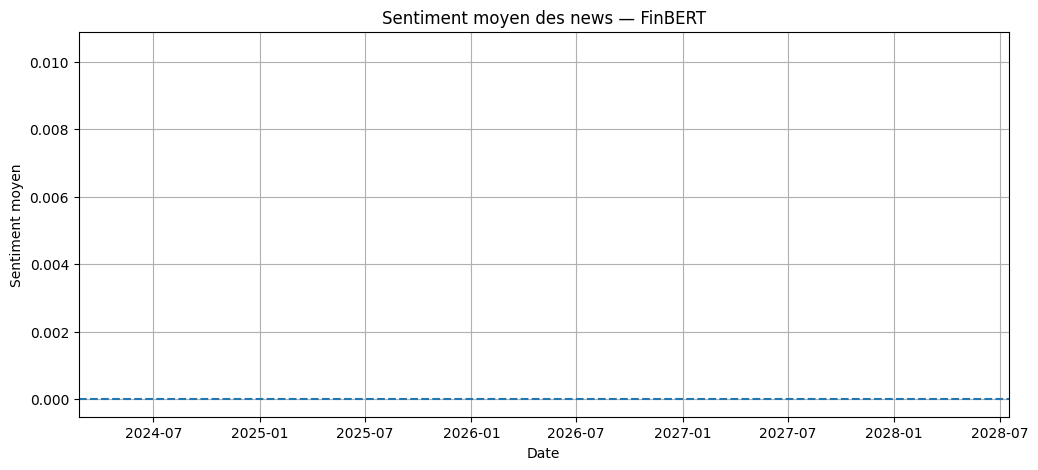

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

daily_sentiment = pd.read_csv("../data/processed/daily_sentiment_finbert.csv")
daily_sentiment["date"] = pd.to_datetime(daily_sentiment["date"])

plt.figure(figsize=(12,5))
plt.plot(daily_sentiment["date"], daily_sentiment["sentiment_mean"])
plt.axhline(0, linestyle="--")
plt.title("Sentiment moyen des news — FinBERT")
plt.xlabel("Date")
plt.ylabel("Sentiment moyen")
plt.grid(True)
plt.show()

In [33]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import pandas as pd

from news_loader import load_yahoo_news

In [34]:
TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA"]

news = load_yahoo_news(TICKERS)

print(news.shape)
news.head()

(0, 0)


""


In [35]:
TICKERS = [
    "AAPL",
    "MSFT",
    "GOOGL",
    "AMZN",
    "META",
    "NVDA",
]

In [36]:
from news_loader import load_yahoo_news

In [37]:
news = load_yahoo_news(TICKERS)

news.head()

""


In [38]:
import os

os.makedirs("../data/raw", exist_ok=True)

In [39]:
news.to_csv("../data/raw/yahoo_news.csv", index=False)

In [40]:
from news_loader import load_yahoo_news

TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA"]

news = load_yahoo_news(TICKERS)

print(news.shape)
news.head()

(0, 0)


""


In [41]:
news = pd.read_csv("../data/raw/boursorama_news.csv")
news["date"] = pd.to_datetime(news["date"])

news.head()

,date,source,text
0,2026-05-06,boursorama,Espace Membre Espace Client Connexion Sur quel...
1,2026-05-06,boursorama,Connexion Sur quel site souhaitez-vous vous co...
2,2026-05-06,boursorama,Bourse Actualités Actualités Points de marchés...
3,2026-05-06,boursorama,Actualités Actualités Points de marchés Actual...
4,2026-05-06,boursorama,Actions Actions Cotations Par marché Internati...


In [42]:
import pandas as pd
import os

news = pd.DataFrame(columns=["ticker", "date", "source", "title", "text", "link"])

os.makedirs("../data/raw", exist_ok=True)
news.to_csv("../data/raw/yahoo_news.csv", index=False)

In [43]:
import pandas as pd

news = pd.read_csv("../data/raw/boursorama_news.csv")
news["date"] = pd.to_datetime(news["date"])

news.head()

,date,source,text
0,2026-05-06,boursorama,Espace Membre Espace Client Connexion Sur quel...
1,2026-05-06,boursorama,Connexion Sur quel site souhaitez-vous vous co...
2,2026-05-06,boursorama,Bourse Actualités Actualités Points de marchés...
3,2026-05-06,boursorama,Actualités Actualités Points de marchés Actual...
4,2026-05-06,boursorama,Actions Actions Cotations Par marché Internati...


In [44]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

from sentiment_news import load_finbert, finbert_score

finbert = load_finbert()

news["sentiment_score"] = news["text"].apply(
    lambda x: finbert_score(x, finbert)
)

/Users/ulrichfossokako/Library/Python/3.9/lib/python/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [45]:
news["sentiment_label"] = pd.cut(
    news["sentiment_score"],
    bins=[-1.01, -0.05, 0.05, 1.01],
    labels=["negative", "neutral", "positive"]
)

daily_sentiment = (
    news.groupby("date")
    .agg(
        sentiment_mean=("sentiment_score", "mean"),
        sentiment_std=("sentiment_score", "std"),
        news_count=("text", "count"),
        sentiment_positive_ratio=("sentiment_label", lambda x: (x == "positive").mean()),
        sentiment_negative_ratio=("sentiment_label", lambda x: (x == "negative").mean()),
    )
    .reset_index()
)

daily_sentiment["sentiment_std"] = daily_sentiment["sentiment_std"].fillna(0)
daily_sentiment.to_csv("../data/processed/daily_sentiment_finbert.csv", index=False)

daily_sentiment.head()

,date,sentiment_mean,sentiment_std,news_count,sentiment_positive_ratio,sentiment_negative_ratio
0,2026-05-06,0.010374,0.076223,161,0.018634,0.0


In [46]:
daily_sentiment = (
    news.groupby("date")
    .agg(
        sentiment_mean=("sentiment_score", "mean"),
        news_count=("text", "count")
    )
    .reset_index()
)

In [47]:
daily_sentiment.head()

,date,sentiment_mean,news_count
0,2026-05-06,0.010374,161
